## 1. Setup

The raw workbook is included at **`data/raw/uci_concrete_data.xlsx`**. The project environment defined in `pyproject.toml` contains the required packages.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

SEED = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "uci_concrete_data.xlsx"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Required UCI workbook not found: {DATA_PATH}"
    )

## 2. Load the dataset

In [2]:
df_raw = pd.read_excel(DATA_PATH)

print("Raw dataset shape:", df_raw.shape)
display(df_raw.head())
df_raw.info()

Raw dataset shape: (1080, 9)


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,172.38,13.610000,172.37,156.760000,4.140000,1006.30000,856.400000,14.000000,29.750889
1,289.00,0.000000,0.00,192.000000,0.000000,913.20000,895.300000,28.000000,25.573354
2,349.00,0.000000,0.00,192.000000,0.000000,1056.00000,809.000000,3.000000,15.871738
3,186.20,124.100000,0.00,185.700000,0.000000,1083.40000,764.300000,7.000000,7.995853
4,NaN,81.031576,NaN,153.423861,6.545475,1079.50586,810.732259,22.280599,58.561221


<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1048 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1050 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1042 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1051 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1080 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1080 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1080 non-null   float64
 7   Age (day)                                              1080 non-null   float64
 8   Concrete compressive strength(MPa, megapascals)        1080 

### Rename columns for easier analysis

The original column names are long, so I rename them to short and readable names.

In [3]:
df = df_raw.copy()

df.columns = [
    "Cement",
    "Slag",
    "FlyAsh",
    "Water",
    "Superplasticizer",
    "CoarseAggregate",
    "FineAggregate",
    "Age",
    "Strength"
]

print("Renamed columns:")
print(df.columns.tolist())

display(df.head())

Renamed columns:
['Cement', 'Slag', 'FlyAsh', 'Water', 'Superplasticizer', 'CoarseAggregate', 'FineAggregate', 'Age', 'Strength']


,Cement,Slag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,Strength
0,172.38,13.610000,172.37,156.760000,4.140000,1006.30000,856.400000,14.000000,29.750889
1,289.00,0.000000,0.00,192.000000,0.000000,913.20000,895.300000,28.000000,25.573354
2,349.00,0.000000,0.00,192.000000,0.000000,1056.00000,809.000000,3.000000,15.871738
3,186.20,124.100000,0.00,185.700000,0.000000,1083.40000,764.300000,7.000000,7.995853
4,NaN,81.031576,NaN,153.423861,6.545475,1079.50586,810.732259,22.280599,58.561221


## 3. Dataset description

Each row represents one concrete mix sample.  
The input features describe the concrete mix composition and the testing age.  
The target variable is **Strength**, i.e. concrete compressive strength in MPa.

### Feature meaning

| Column | Meaning | Unit |
|---|---|---|
| Cement | Cement content | kg/m³ |
| Slag | Blast furnace slag content | kg/m³ |
| FlyAsh | Fly ash content | kg/m³ |
| Water | Water content | kg/m³ |
| Superplasticizer | Superplasticizer content | kg/m³ |
| CoarseAggregate | Coarse aggregate content | kg/m³ |
| FineAggregate | Fine aggregate content | kg/m³ |
| Age | Age at testing | days |
| Strength | Concrete compressive strength | MPa |

In [4]:
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Input features:", df.drop(columns=["Strength"]).columns.tolist())
print("Target variable: Strength")

display(df.describe().T)

Dataset shape: (1080, 9)
Number of rows: 1080
Number of columns: 9
Input features: ['Cement', 'Slag', 'FlyAsh', 'Water', 'Superplasticizer', 'CoarseAggregate', 'FineAggregate', 'Age']
Target variable: Strength


,count,mean,std,min,25%,50%,75%,max
Cement,1048.0,281.491308,104.162471,102.000000,194.680000,274.000000,350.00000,540.000000
Slag,1050.0,73.794694,86.110710,0.000000,0.000000,22.000000,142.72500,359.400000
FlyAsh,1042.0,54.148015,63.786094,0.000000,0.000000,0.000000,118.27000,200.100000
Water,1051.0,181.448016,21.322325,121.750000,164.900000,185.000000,192.00000,247.000000
Superplasticizer,1080.0,6.231984,5.944312,0.000000,0.000000,6.350000,10.16000,32.200000
CoarseAggregate,1080.0,973.076670,77.447901,801.000000,932.000000,968.000000,1029.40000,1145.000000
FineAggregate,1080.0,773.390569,79.864558,594.000000,732.050000,779.320000,822.65000,992.600000
Age,1080.0,45.392082,62.353966,1.000000,14.000000,28.000000,56.00000,365.000000
Strength,1080.0,35.907088,16.535634,2.331808,23.880001,34.346247,46.08949,82.599225


## 4. Missing-value inspection

In [5]:
missing_summary = pd.DataFrame({
    "MissingCount": df.isna().sum(),
    "MissingPercent": 100 * df.isna().mean()
}).sort_values("MissingCount", ascending=False)

display(missing_summary)

rows_with_nan = df[df.isna().any(axis=1)]
print("Number of rows with at least one missing value:", len(rows_with_nan))
display(rows_with_nan.head(10))

,MissingCount,MissingPercent
FlyAsh,38,3.518519
Cement,32,2.962963
Slag,30,2.777778
Water,29,2.685185
Superplasticizer,0,0.000000
CoarseAggregate,0,0.000000
FineAggregate,0,0.000000
Age,0,0.000000
Strength,0,0.000000


Number of rows with at least one missing value: 50


,Cement,Slag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,Strength
4,NaN,81.031576,NaN,153.423861,6.545475,1079.505860,810.732259,22.280599,58.561221
8,435.754987,NaN,NaN,157.843505,0.000000,963.416877,863.506280,28.000000,57.541884
10,NaN,2.992412,NaN,208.394391,11.033900,879.140182,749.599601,27.229554,31.758036
39,NaN,82.007080,NaN,NaN,7.689242,985.578293,782.929604,73.949492,46.052058
61,404.226077,135.294222,NaN,NaN,16.740204,956.625139,768.010512,75.377712,62.254227
76,NaN,49.146471,38.593547,NaN,2.412097,1072.059578,752.059578,28.000000,58.494351
88,NaN,NaN,NaN,NaN,2.505224,912.504717,767.983030,58.935224,33.246992
95,NaN,NaN,NaN,134.090267,20.719996,865.076257,971.251594,9.405132,43.950879
137,NaN,NaN,NaN,NaN,8.723500,887.756905,695.309847,18.743350,30.629566
147,329.359321,NaN,53.101941,178.806908,5.024586,891.477455,785.161069,28.000000,42.709470


### Missing-data handling options

| Option | What it means | Advantage | Disadvantage |
|---|---|---|---|
| Drop rows | Remove rows with missing values | Simple and clean | Some data is lost |
| Simple imputation | Replace NaNs with mean/median | Keeps all rows | Can distort distributions |
| Model-based imputation | Predict missing values using other features | More informed | More complex and may introduce bias |
| Models that handle NaNs | Use algorithms that accept missing values | Less preprocessing | Not available for all models |

### Decision for this exercise

I have drop the artificial NaN rows, we will use **drop rows** for the final cleaned dataset.

In [6]:
# Optional preview: what simple imputation would do
numeric_cols = df.columns.tolist()

mean_imputer = SimpleImputer(strategy="mean")
median_imputer = SimpleImputer(strategy="median")

df_mean_imputed = pd.DataFrame(mean_imputer.fit_transform(df), columns=numeric_cols)
df_median_imputed = pd.DataFrame(median_imputer.fit_transform(df), columns=numeric_cols)

print("Original shape:", df.shape)
print("Mean-imputed shape:", df_mean_imputed.shape)
print("Median-imputed shape:", df_median_imputed.shape)
print("These are shown only for comparison. For this exercise, we will drop NaN rows.")

Original shape: (1080, 9)
Mean-imputed shape: (1080, 9)
Median-imputed shape: (1080, 9)
These are shown only for comparison. For this exercise, we will drop NaN rows.


## 5. Drop artificial NaN rows

In [7]:
df_clean = df.dropna().copy()

print("Shape before dropping NaN rows:", df.shape)
print("Shape after dropping NaN rows:", df_clean.shape)
print("Number of rows removed:", df.shape[0] - df_clean.shape[0])

display(df_clean.isna().sum())

Shape before dropping NaN rows: (1080, 9)
Shape after dropping NaN rows: (1030, 9)
Number of rows removed: 50


Cement              0
Slag                0
FlyAsh              0
Water               0
Superplasticizer    0
CoarseAggregate     0
FineAggregate       0
Age                 0
Strength            0
dtype: int64

## 6. Duplicate inspection

In [8]:
duplicate_count = df_clean.duplicated().sum()
print("Number of exact duplicate rows:", duplicate_count)

duplicates = df_clean[df_clean.duplicated(keep=False)].sort_values(list(df_clean.columns))
display(duplicates.head(20))

Number of exact duplicate rows: 25


,Cement,Slag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,Strength
206,252.0,0.0,0.0,185.0,0.0,1111.0,784.0,28.0,19.691435
338,252.0,0.0,0.0,185.0,0.0,1111.0,784.0,28.0,19.691435
37,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3.0,35.301171
46,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3.0,35.301171
126,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3.0,35.301171
1038,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3.0,35.301171
45,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7.0,55.895819
231,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7.0,55.895819
762,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7.0,55.895819
284,362.6,189.0,0.0,164.9,11.6,944.7,755.8,28.0,71.298713


### Duplicate decision

For a clean ML pipeline, exact duplicate rows are removed.  
However, in a real experimental context, one should first check whether duplicates are true repeated measurements or accidental data repetitions.

In [9]:
df_no_duplicates = df_clean.drop_duplicates().copy()

print("Shape before duplicate removal:", df_clean.shape)
print("Shape after duplicate removal:", df_no_duplicates.shape)
print("Number of duplicate rows removed:", df_clean.shape[0] - df_no_duplicates.shape[0])

# This will be the main cleaned dataset for the rest of the notebook
df_model = df_no_duplicates.copy()

Shape before duplicate removal: (1030, 9)
Shape after duplicate removal: (1005, 9)
Number of duplicate rows removed: 25


## 7. Statistical analysis

### What statistical analyses tell us

Statistical analysis helps us understand:

- Mean and typical values
- Range of each feature
- Variance and standard deviation
- Skewness
- Missing values
- Outliers
- Feature-target correlations
- Whether scaling may be needed
- Whether feature engineering may be useful

In [10]:
summary_stats = df_model.describe().T
summary_stats["variance"] = df_model.var(numeric_only=True)
summary_stats["skewness"] = df_model.skew(numeric_only=True)
summary_stats["coefficient_of_variation"] = df_model.std(numeric_only=True) / df_model.mean(numeric_only=True)

display(summary_stats)

,count,mean,std,min,25%,50%,75%,max,variance,skewness,coefficient_of_variation
Cement,1005.0,278.629055,104.345003,102.000000,190.680000,265.000000,349.00000,540.000000,10887.879601,0.564997,0.374494
Slag,1005.0,72.043134,86.170555,0.000000,0.000000,20.000000,142.50000,359.400000,7425.364576,0.855246,1.196097
FlyAsh,1005.0,55.535075,64.207448,0.000000,0.000000,0.000000,118.27000,200.100000,4122.596436,0.497324,1.156160
Water,1005.0,182.074378,21.340740,121.750000,166.610000,185.700000,192.94000,247.000000,455.427169,0.034119,0.117209
Superplasticizer,1005.0,6.031647,5.919559,0.000000,0.000000,6.100000,10.00000,32.200000,35.041179,0.981572,0.981417
CoarseAggregate,1005.0,974.376468,77.579534,801.000000,932.000000,968.000000,1031.00000,1145.000000,6018.584052,-0.065242,0.079620
FineAggregate,1005.0,772.686617,80.339851,594.000000,724.300000,780.000000,822.20000,992.600000,6454.491667,-0.252323,0.103975
Age,1005.0,45.856716,63.734692,1.000000,7.000000,28.000000,56.00000,365.000000,4062.110923,3.253974,1.389866
Strength,1005.0,35.250273,16.284808,2.331808,23.523542,33.798114,44.86834,82.599225,265.194960,0.395653,0.461977


## 8. Variance and standard deviation

This dataset exhibits considerable variance.  
Features such as Cement, Slag, FlyAsh, aggregates, and Age show large spreads.  
However, raw variance depends on units and scale, so standard deviation, coefficient of variation, and visual distributions are more useful than variance alone.

In [11]:
variation_table = pd.DataFrame({
    "Mean": df_model.mean(numeric_only=True),
    "Std": df_model.std(numeric_only=True),
    "Variance": df_model.var(numeric_only=True),
    "CoeffVariation": df_model.std(numeric_only=True) / df_model.mean(numeric_only=True)
}).sort_values("Std", ascending=False)

display(variation_table)

,Mean,Std,Variance,CoeffVariation
Cement,278.629055,104.345003,10887.879601,0.374494
Slag,72.043134,86.170555,7425.364576,1.196097
FineAggregate,772.686617,80.339851,6454.491667,0.103975
CoarseAggregate,974.376468,77.579534,6018.584052,0.079620
FlyAsh,55.535075,64.207448,4122.596436,1.156160
Age,45.856716,63.734692,4062.110923,1.389866
Water,182.074378,21.340740,455.427169,0.117209
Strength,35.250273,16.284808,265.194960,0.461977
Superplasticizer,6.031647,5.919559,35.041179,0.981417


### Which features show the highest variation?

We can rank features in two ways given as follow:

1. **Absolute variation** using standard deviation  
2. **Relative variation** using coefficient of variation  

Features with many zero values, such as FlyAsh, Slag, and Superplasticizer, may show high relative variation.

In [12]:
print("Highest absolute variation by standard deviation:")
display(variation_table.sort_values("Std", ascending=False))

print("Highest relative variation by coefficient of variation:")
display(variation_table.sort_values("CoeffVariation", ascending=False))

Highest absolute variation by standard deviation:


,Mean,Std,Variance,CoeffVariation
Cement,278.629055,104.345003,10887.879601,0.374494
Slag,72.043134,86.170555,7425.364576,1.196097
FineAggregate,772.686617,80.339851,6454.491667,0.103975
CoarseAggregate,974.376468,77.579534,6018.584052,0.079620
FlyAsh,55.535075,64.207448,4122.596436,1.156160
Age,45.856716,63.734692,4062.110923,1.389866
Water,182.074378,21.340740,455.427169,0.117209
Strength,35.250273,16.284808,265.194960,0.461977
Superplasticizer,6.031647,5.919559,35.041179,0.981417


Highest relative variation by coefficient of variation:


,Mean,Std,Variance,CoeffVariation
Age,45.856716,63.734692,4062.110923,1.389866
Slag,72.043134,86.170555,7425.364576,1.196097
FlyAsh,55.535075,64.207448,4122.596436,1.156160
Superplasticizer,6.031647,5.919559,35.041179,0.981417
Strength,35.250273,16.284808,265.194960,0.461977
Cement,278.629055,104.345003,10887.879601,0.374494
Water,182.074378,21.340740,455.427169,0.117209
FineAggregate,772.686617,80.339851,6454.491667,0.103975
CoarseAggregate,974.376468,77.579534,6018.584052,0.079620


## 9. Distribution of each feature

Inspect which features are skewed, bimodal, or near constant.

### Expected observations

- **Age** is usually strongly skewed because many tests are performed at common ages such as 7, 14, 28, 56, or 90 days, but some samples are much older.
- **FlyAsh**, **Slag**, and **Superplasticizer** are zero-heavy because many mixes do not contain these materials.
- No feature is expected to be truly constant.

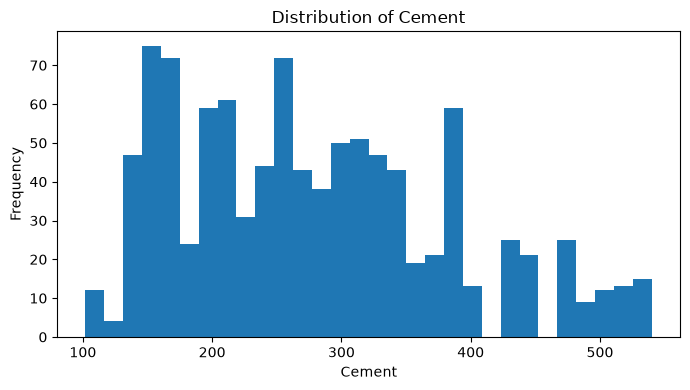

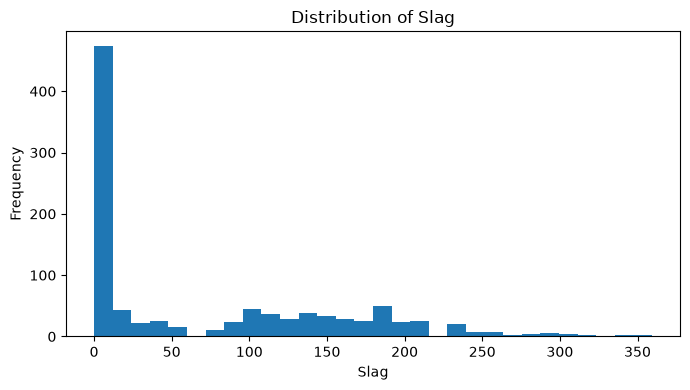

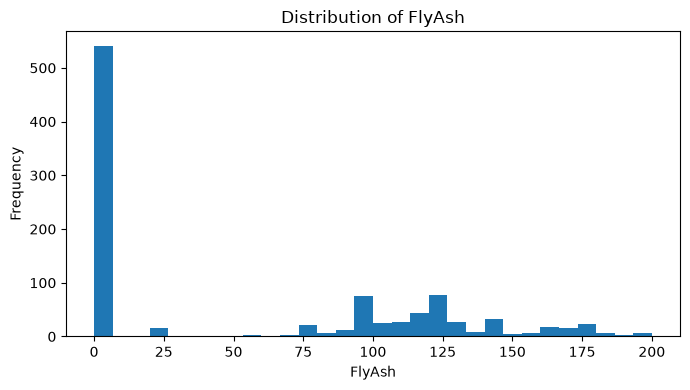

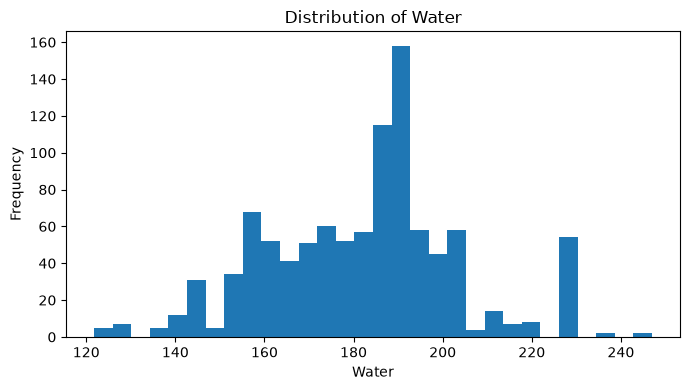

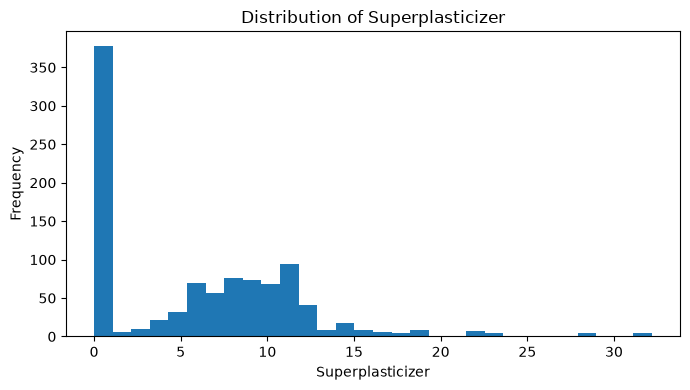

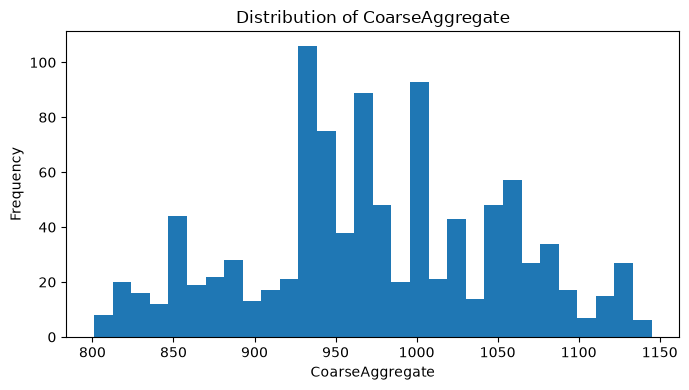

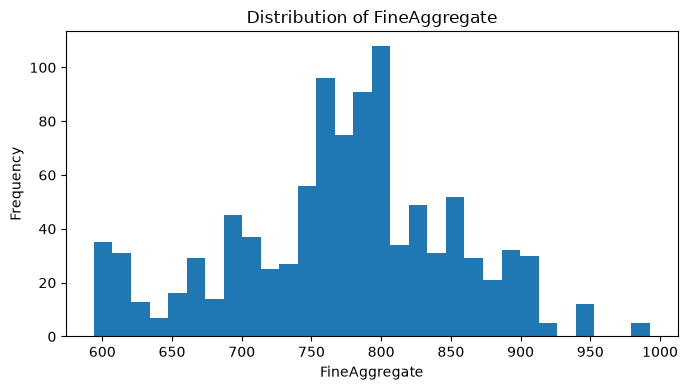

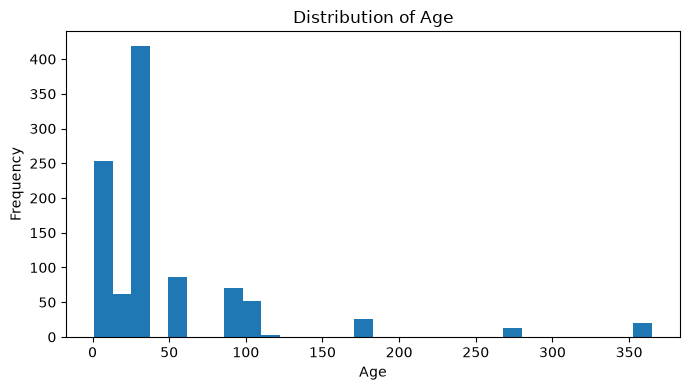

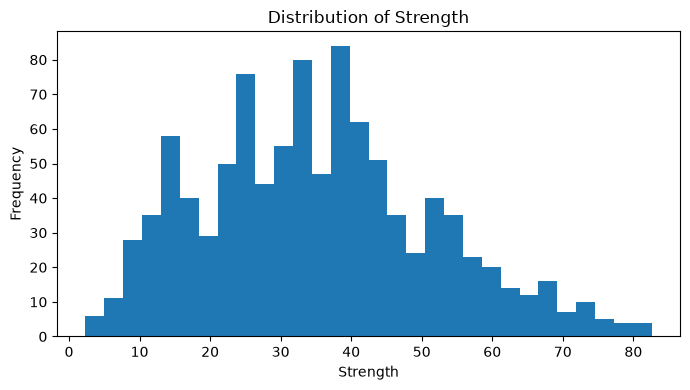

In [13]:
# Histogram of each feature
for col in df_model.columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df_model[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

In [14]:
skewness_table = pd.DataFrame({
    "Skewness": df_model.skew(numeric_only=True),
    "UniqueValues": df_model.nunique(),
    "ZeroCount": (df_model == 0).sum(),
    "ZeroPercent": 100 * (df_model == 0).mean()
}).sort_values("Skewness", ascending=False)

display(skewness_table)

,Skewness,UniqueValues,ZeroCount,ZeroPercent
Age,3.253974,14,0,0.000000
Superplasticizer,0.981572,155,378,37.611940
Slag,0.855246,187,465,46.268657
Cement,0.564997,280,0,0.000000
FlyAsh,0.497324,163,541,53.830846
Strength,0.395653,938,0,0.000000
Water,0.034119,205,0,0.000000
CoarseAggregate,-0.065242,284,0,0.000000
FineAggregate,-0.252323,304,0,0.000000


### Observation for: skewed, bimodal, or near constant

- **Age** is strongly skewed because of common testing ages and some very high ages.
- **FlyAsh**, **Slag**, and **Superplasticizer** are zero-heavy because many mixtures do not include them.
- No feature is truly constant.
- Water has lower variation compared with many other mix components, but it is not constant.

## 10. Pairwise correlations with the target

Correlation helps us understand the linear relationship between each feature and compressive strength.

Important limitation:  
Correlation is only a pairwise linear measure. Concrete strength depends on non-linear and ratio-based relationships, so correlation alone is not enough.

In [15]:
corr_matrix = df_model.corr(numeric_only=True)
corr_with_strength = corr_matrix["Strength"].drop("Strength").sort_values(ascending=False)

display(corr_with_strength.to_frame("CorrelationWithStrength"))

,CorrelationWithStrength
Cement,0.488283
Superplasticizer,0.344225
Age,0.337371
Slag,0.103370
FlyAsh,-0.080648
CoarseAggregate,-0.144710
FineAggregate,-0.186457
Water,-0.269606


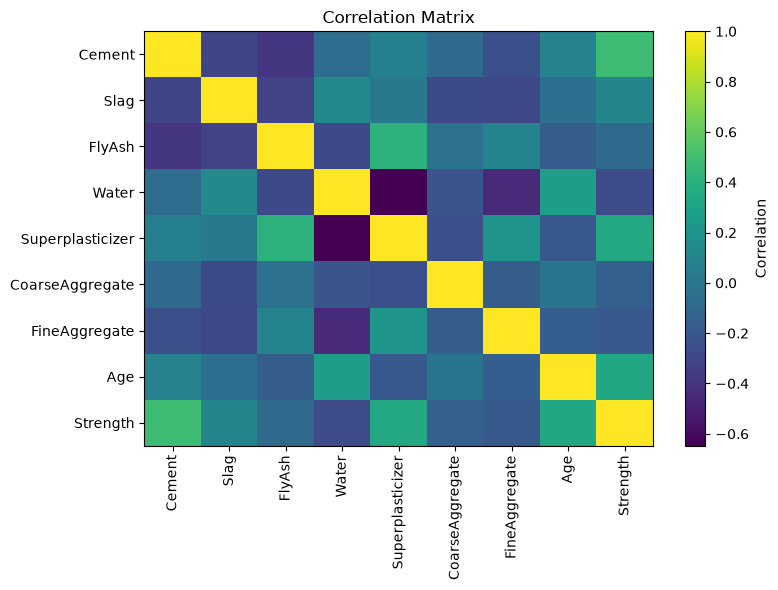

In [16]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Correlations with strength

Typical interpretation:

- Cement usually has a positive relationship with strength.
- Age usually has a positive relationship with strength.
- Superplasticizer often has a positive relationship, partly because it helps reduce water demand and improve workability.
- Water often has a negative relationship with strength.
- FlyAsh and Slag may not show very strong simple correlation because their effect depends on age, binder composition, and replacement ratios.

The most important point is that concrete behavior is not captured fully by individual correlations. Engineered ratios such as **water-to-binder ratio** are often more physically meaningful.

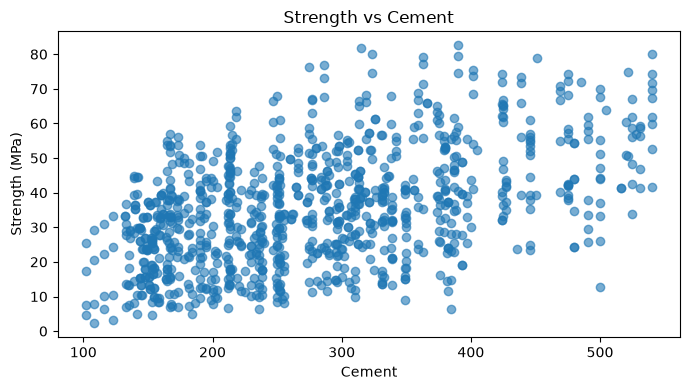

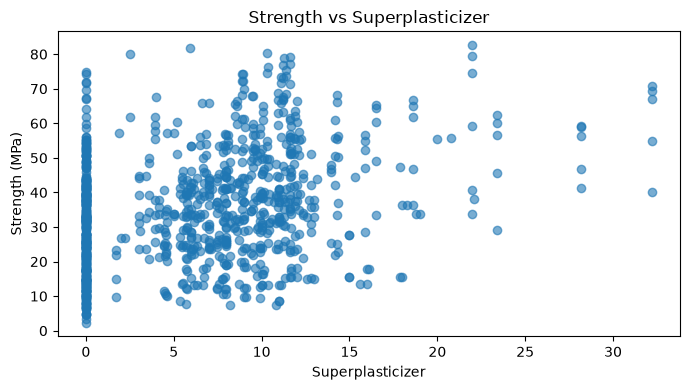

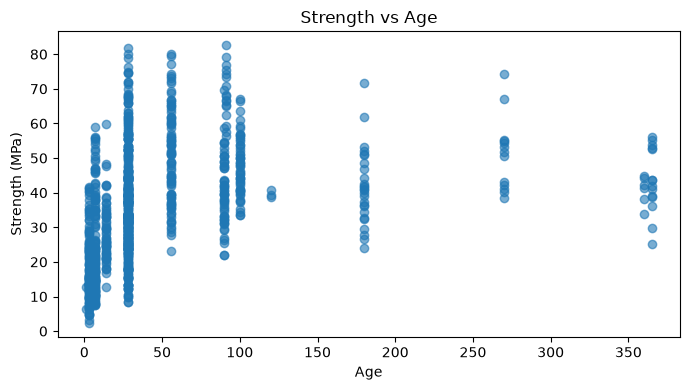

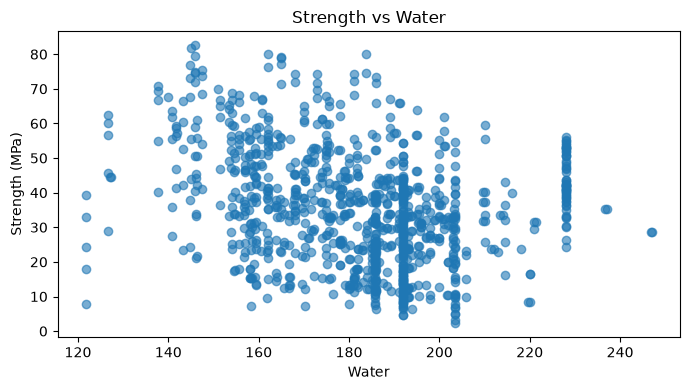

In [17]:
# Scatter plots for top absolute correlations
top_corr_features = corr_with_strength.abs().sort_values(ascending=False).head(4).index

for col in top_corr_features:
    plt.figure(figsize=(7, 4))
    plt.scatter(df_model[col], df_model["Strength"], alpha=0.6)
    plt.xlabel(col)
    plt.ylabel("Strength (MPa)")
    plt.title(f"Strength vs {col}")
    plt.tight_layout()
    plt.show()

## 11. Outlier inspection using boxplots and IQR

The Week 2 checklist asks for outlier / boxplot analysis.

Important:  
Outliers should not be removed automatically. In concrete data, an extreme value may be physically valid, such as very old curing age or a special mix design.

/var/folders/xn/yf_zt18118s94460bbl683j80000gn/T/ipykernel_10738/3095372145.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_model[col].dropna(), vert=True)


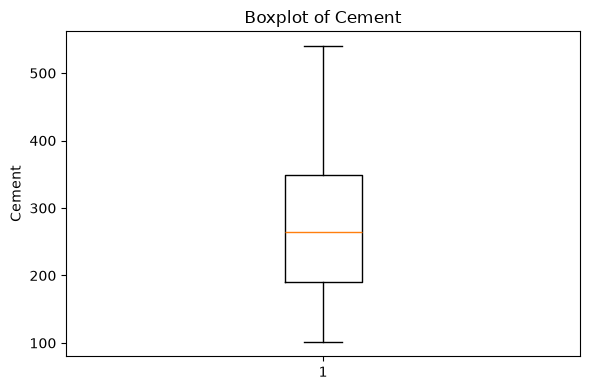

/var/folders/xn/yf_zt18118s94460bbl683j80000gn/T/ipykernel_10738/3095372145.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_model[col].dropna(), vert=True)


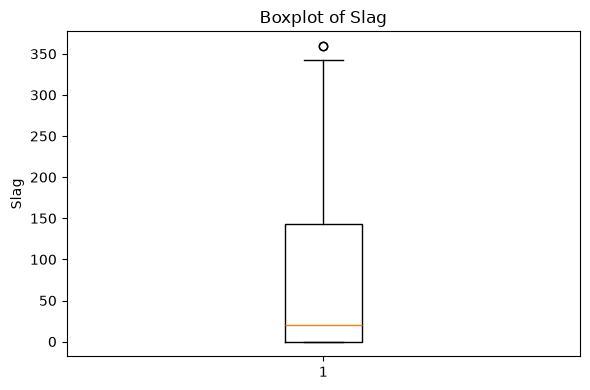

/var/folders/xn/yf_zt18118s94460bbl683j80000gn/T/ipykernel_10738/3095372145.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_model[col].dropna(), vert=True)


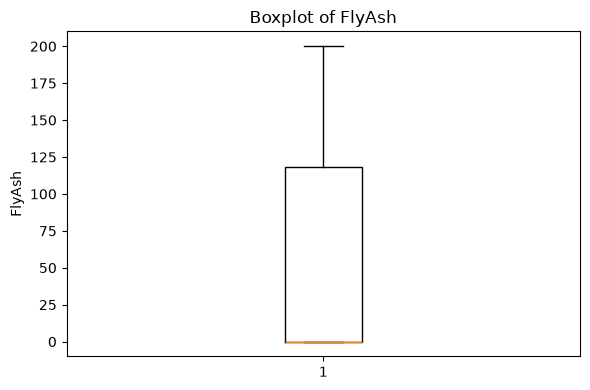

/var/folders/xn/yf_zt18118s94460bbl683j80000gn/T/ipykernel_10738/3095372145.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_model[col].dropna(), vert=True)


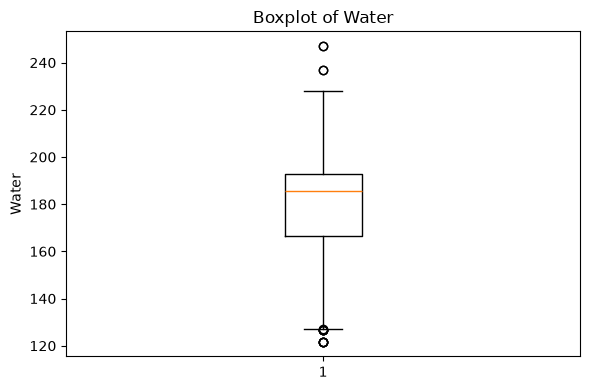

/var/folders/xn/yf_zt18118s94460bbl683j80000gn/T/ipykernel_10738/3095372145.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_model[col].dropna(), vert=True)


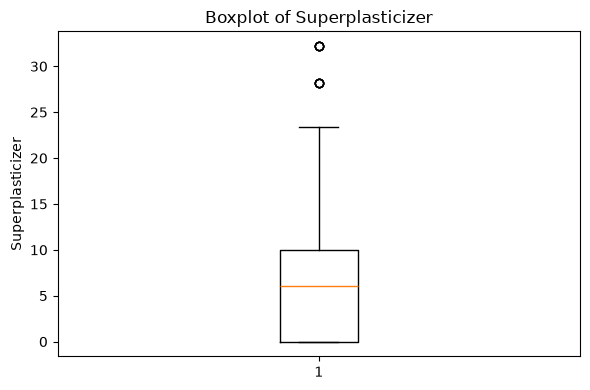

/var/folders/xn/yf_zt18118s94460bbl683j80000gn/T/ipykernel_10738/3095372145.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_model[col].dropna(), vert=True)


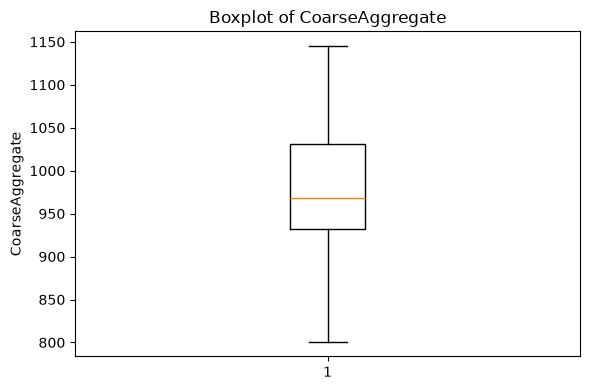

/var/folders/xn/yf_zt18118s94460bbl683j80000gn/T/ipykernel_10738/3095372145.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_model[col].dropna(), vert=True)


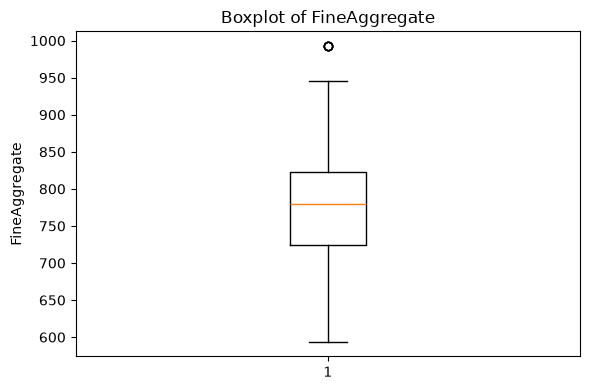

/var/folders/xn/yf_zt18118s94460bbl683j80000gn/T/ipykernel_10738/3095372145.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_model[col].dropna(), vert=True)


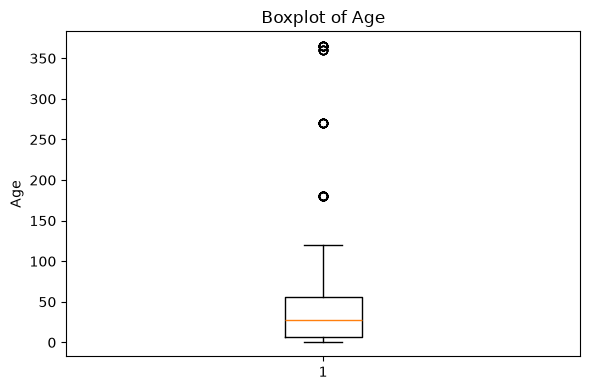

/var/folders/xn/yf_zt18118s94460bbl683j80000gn/T/ipykernel_10738/3095372145.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_model[col].dropna(), vert=True)


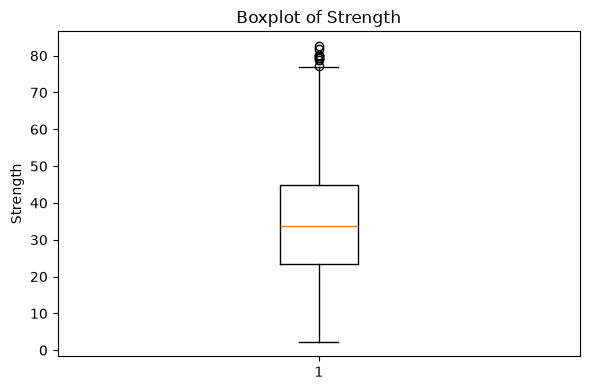

In [18]:
# Boxplot of each feature
for col in df_model.columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df_model[col].dropna(), vert=True)
    plt.ylabel(col)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

In [19]:
Q1 = df_model.quantile(0.25, numeric_only=True)
Q3 = df_model.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1

outlier_mask = (df_model < (Q1 - 1.5 * IQR)) | (df_model > (Q3 + 1.5 * IQR))
outlier_counts = outlier_mask.sum().sort_values(ascending=False)

display(outlier_counts.to_frame("OutlierCount_IQR"))

,OutlierCount_IQR
Age,59
Water,15
Superplasticizer,10
Strength,8
FineAggregate,5
Slag,2
Cement,0
FlyAsh,0
CoarseAggregate,0


### Outliers

Boxplots and IQR counts help identify extreme values.  
In this dataset, outliers are likely to appear especially in **Age**, and sometimes in **Superplasticizer**, **Water**, or **Strength**.

I should inspect them carefully before removal.  
For Week 2, our goal is to identify and discuss outliers, not automatically delete them.

## 12. Optional physically meaningful engineered features

Yeh (1998) and concrete technology both show that ratios are important.  
The raw dataset includes ingredient quantities, but not ratios such as water-to-binder ratio.

I have created additional features:

- TotalBinder = Cement + FlyAsh + Slag
- WaterToCement = Water / Cement
- WaterToBinder = Water / TotalBinder
- SPToBinder = Superplasticizer / TotalBinder
- FlyAshToBinder = FlyAsh / TotalBinder
- SlagToBinder = Slag / TotalBinder

In [20]:
df_engineered = df_model.copy()

df_engineered["TotalBinder"] = (
    df_engineered["Cement"] + df_engineered["FlyAsh"] + df_engineered["Slag"]
)

df_engineered["WaterToCement"] = df_engineered["Water"] / df_engineered["Cement"]
df_engineered["WaterToBinder"] = df_engineered["Water"] / df_engineered["TotalBinder"]
df_engineered["SPToBinder"] = df_engineered["Superplasticizer"] / df_engineered["TotalBinder"]
df_engineered["FlyAshToBinder"] = df_engineered["FlyAsh"] / df_engineered["TotalBinder"]
df_engineered["SlagToBinder"] = df_engineered["Slag"] / df_engineered["TotalBinder"]

display(df_engineered.head())

engineered_corr = df_engineered.corr(numeric_only=True)["Strength"].sort_values(ascending=False)
display(engineered_corr.to_frame("CorrelationWithStrength"))

,Cement,Slag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,Strength,TotalBinder,WaterToCement,WaterToBinder,SPToBinder,FlyAshToBinder,SlagToBinder
0,172.38,13.61,172.37,156.76,4.14,1006.3,856.4,14.0,29.750889,358.36,0.909386,0.437437,0.011553,0.480997,0.037979
1,289.00,0.00,0.00,192.00,0.00,913.2,895.3,28.0,25.573354,289.00,0.664360,0.664360,0.000000,0.000000,0.000000
2,349.00,0.00,0.00,192.00,0.00,1056.0,809.0,3.0,15.871738,349.00,0.550143,0.550143,0.000000,0.000000,0.000000
3,186.20,124.10,0.00,185.70,0.00,1083.4,764.3,7.0,7.995853,310.30,0.997315,0.598453,0.000000,0.000000,0.399936
5,277.00,0.00,0.00,191.00,0.00,968.0,856.0,360.0,33.701587,277.00,0.689531,0.689531,0.000000,0.000000,0.000000


,CorrelationWithStrength
Strength,1.000000
TotalBinder,0.598086
Cement,0.488283
Superplasticizer,0.344225
Age,0.337371
SPToBinder,0.222176
Slag,0.103370
SlagToBinder,0.002541
FlyAsh,-0.080648
FlyAshToBinder,-0.141197


## 13. Prepare data pipeline for the coming weeks.

Prepare the data pipeline to be fit to a model next week.

I will prepare:

1. Cleaned dataset  
2. Optional engineered dataset  
3. X/y separation  
4. Train/validation/test split  
5. K-fold cross-validation setup  
6. Scaling pipeline for models that need scaling

In [21]:
# Choose whether to use engineered features for next week's modeling
USE_ENGINEERED_FEATURES = True

if USE_ENGINEERED_FEATURES:
    data_for_modeling = df_engineered.copy()
else:
    data_for_modeling = df_model.copy()

X = data_for_modeling.drop(columns=["Strength"])
y = data_for_modeling["Strength"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Features:")
print(X.columns.tolist())

Feature matrix shape: (1005, 14)
Target vector shape: (1005,)
Features:
['Cement', 'Slag', 'FlyAsh', 'Water', 'Superplasticizer', 'CoarseAggregate', 'FineAggregate', 'Age', 'TotalBinder', 'WaterToCement', 'WaterToBinder', 'SPToBinder', 'FlyAshToBinder', 'SlagToBinder']


### Train-test split

The data is divided into two sets:

- **Training set:** used for fitting and cross-validation  
- **Test set:** kept aside for final evaluation  

Here we use:

- 80% training
- 20% test

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (804, 14) (804,)
Test set: (201, 14) (201,)


### K-fold cross-validation setup

K-fold cross-validation gives a more reliable performance estimate during model comparison.  
The later UCI experiments use 4-fold cross-validation on the training data, following the project evaluation protocol.

In [23]:
kfold = KFold(n_splits=4, shuffle=True, random_state=SEED)

print("K-fold setup:")
print(kfold)

# Example: show fold sizes
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train), start=1):
    print(f"Fold {fold}: train size = {len(train_idx)}, validation size = {len(val_idx)}")

K-fold setup:
KFold(n_splits=4, random_state=42, shuffle=True)
Fold 1: train size = 603, validation size = 201
Fold 2: train size = 603, validation size = 201
Fold 3: train size = 603, validation size = 201
Fold 4: train size = 603, validation size = 201


### Scaling pipeline

Scaling is important for models such as:

- Linear Regression with regularization
- Ridge / Lasso / Elastic Net

In [24]:
scaled_preprocess = Pipeline(steps=[
    ("scaler", StandardScaler())
])

scaled_preprocess

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [25]:
clean_path = PROCESSED_DIR / "uci_concrete_clean.csv"
engineered_path = PROCESSED_DIR / "uci_concrete_clean_engineered.csv"

df_model.to_csv(clean_path, index=False)
df_engineered.to_csv(engineered_path, index=False)